# 01 Data Acquisition

Executable reporting notebook for the Google Play data acquisition phase. It reads existing local summaries, raw-count evidence, aggregate EDA metrics, and saved figures. It does not scrape Google Play and it handles ignored raw files gracefully.


## CRISP-DM Stage

Data Understanding. This notebook validates the Google Play review acquisition output before preprocessing.


In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import Image, Markdown, display


def find_project_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "CLAUDE.md").exists() and (candidate / "ml-service").exists():
            return candidate
    raise RuntimeError("Could not find SentiRank project root from current working directory.")


PROJECT_ROOT = find_project_root()
ML_SERVICE_DIR = PROJECT_ROOT / "ml-service"
DATASETS_DIR = PROJECT_ROOT / "datasets"
DOCS_FIGURES_DIR = PROJECT_ROOT / "docs" / "figures"


def load_json(path: Path):
    if not path.exists():
        display(Markdown(f"Missing JSON: `{path.relative_to(PROJECT_ROOT)}`"))
        return None
    with path.open("r", encoding="utf-8") as file:
        return json.load(file)


def load_csv(path: Path, **kwargs):
    if not path.exists():
        display(Markdown(f"Missing CSV: `{path.relative_to(PROJECT_ROOT)}`"))
        return None
    return pd.read_csv(path, **kwargs)


def show_json_as_table(payload, title: str):
    if payload is None:
        return
    display(Markdown(f"### {title}"))
    try:
        table = pd.json_normalize(payload, sep=".").T.reset_index()
        table.columns = ["field", "value"]
        display(table)
    except Exception as exc:
        display(Markdown(f"Could not tabulate JSON payload: `{exc}`"))
        display(payload)


def show_csv_preview(path: Path, title: str, rows: int = 10):
    data = load_csv(path)
    if data is None:
        return None
    display(Markdown(f"### {title}"))
    display(data.head(rows))
    if len(data) > rows:
        display(Markdown(f"Rows: `{len(data)}`. Showing first `{rows}` rows."))
    return data


def show_figures(figure_paths: list[Path], title: str):
    display(Markdown(f"## {title}"))
    shown = 0
    for figure_path in figure_paths:
        if figure_path.exists():
            display(Markdown(f"**{figure_path.relative_to(PROJECT_ROOT)}**"))
            display(Image(filename=str(figure_path)))
            shown += 1
        else:
            display(Markdown(f"Missing figure: `{figure_path.relative_to(PROJECT_ROOT)}`"))
    if shown == 0:
        display(Markdown("No figures were available to display."))

print(f"Project root: {PROJECT_ROOT}")


Project root: C:\Data Central\Documents\Skripsi Ahmad Zaky Humami\Project Skripsi\SentiRank


## Optional Safe Script Check

The only acquisition script command included here is a dry run. Keep `RUN_SCRAPE_DRY_RUN = False` unless you specifically want to inspect the planned scraper configuration. This cell never runs live scraping.


In [2]:
import subprocess
import sys

RUN_SCRAPE_DRY_RUN = False

if RUN_SCRAPE_DRY_RUN:
    command = [sys.executable, "scripts/scrape_reviews.py", "--dry-run"]
    result = subprocess.run(command, cwd=ML_SERVICE_DIR, text=True, capture_output=True, check=False)
    print(result.stdout)
    if result.stderr:
        print(result.stderr)
    print(f"Return code: {result.returncode}")
else:
    display(Markdown("Dry-run command is available but skipped by default: `python scripts/scrape_reviews.py --dry-run`."))


Dry-run command is available but skipped by default: `python scripts/scrape_reviews.py --dry-run`.

## Load Acquisition Summaries

These files are generated artifacts and may be absent on a fresh clone because raw outputs are ignored by Git.


In [3]:
RAW_DIR = DATASETS_DIR / "raw"
summary_files = {
    "Data acquisition summary": RAW_DIR / "data_acquisition_summary.json",
    "Scraping summary": RAW_DIR / "scraping_summary.json",
}

acquisition_summaries = {name: load_json(path) for name, path in summary_files.items()}
for name, payload in acquisition_summaries.items():
    show_json_as_table(payload, name)


### Data acquisition summary

,field,value
0,duplicate_external_id_count,0
1,generated_at,2026-05-14T05:47:44.648839+00:00
2,missing_content_count,0
3,missing_rating_count,0
4,rating_3_limitation_note,"Rating 3 target was 30,000 reviews, but only 2..."
5,reviewed_at_max,2026-05-13T02:16:04
6,reviewed_at_min,2014-07-06T20:34:44
7,text_length_max,636
8,text_length_mean,63.376184
9,text_length_median,36.0


### Scraping summary

,field,value
0,app_id,com.spotify.music
1,app_title,Spotify: Music dan Podcast
2,batch_size,200
3,country,id
4,full_scraping_note,"Full 100,000-review scraping is not automatic...."
5,generated_at,2026-05-14T04:18:30.235756+00:00
6,lang,id
7,limit,None
8,sleep_seconds,2.0
9,source_name,google_play_spotify_id


## Raw Per-Rating Row Counts

Counts are computed only if `reviews_rating_1_raw.csv` through `reviews_rating_5_raw.csv` exist locally.


In [4]:
TARGET_QUOTA = {1: 20000, 2: 15000, 3: 30000, 4: 15000, 5: 20000}
row_count_records = []

for rating, target in TARGET_QUOTA.items():
    csv_path = RAW_DIR / f"reviews_rating_{rating}_raw.csv"
    if csv_path.exists():
        count = len(pd.read_csv(csv_path))
        status = "available"
    else:
        count = None
        status = "missing ignored local file"
    row_count_records.append({
        "rating": rating,
        "target_rows": target,
        "actual_rows": count,
        "achievement_pct": (count / target * 100) if count is not None and target else None,
        "status": status,
    })

raw_counts_df = pd.DataFrame(row_count_records)
display(raw_counts_df)

available_total = raw_counts_df["actual_rows"].dropna().sum()
if available_total:
    display(Markdown(f"Available local raw rows: `{int(available_total):,}`."))


,rating,target_rows,actual_rows,achievement_pct,status
0,1,20000,20000,100.000000,available
1,2,15000,15000,100.000000,available
2,3,30000,27782,92.606667,available
3,4,15000,15000,100.000000,available
4,5,20000,20000,100.000000,available


Available local raw rows: `97,782`.

## EDA Metrics

Aggregate metrics are read from `datasets/outputs/eda/01_data_acquisition/`. These files are small dashboard/thesis artifacts.


In [5]:
EDA01_DIR = DATASETS_DIR / "outputs" / "eda" / "01_data_acquisition"
metric_files = [
    "rating_distribution_raw.csv",
    "sentiment_distribution_raw.csv",
    "text_length_histogram_raw.csv",
    "temporal_distribution_monthly_raw.csv",
    "temporal_distribution_monthly_by_rating.csv",
    "scraping_quota_achievement.csv",
    "missing_value_summary.csv",
]

loaded_eda01_tables = {}
for filename in metric_files:
    table = show_csv_preview(EDA01_DIR / filename, filename, rows=12)
    if table is not None:
        loaded_eda01_tables[filename] = table

for filename in ["text_length_summary_raw.json", "rating_distribution_raw.json", "sentiment_distribution_raw.json", "scraping_quota_achievement.json", "missing_value_summary.json"]:
    show_json_as_table(load_json(EDA01_DIR / filename), filename)


### rating_distribution_raw.csv

,rating,count
0,1,20000
1,2,15000
2,3,27782
3,4,15000
4,5,20000


### sentiment_distribution_raw.csv

,initial_sentiment,count
0,Negative,35000
1,Neutral,27782
2,Positive,35000


### text_length_histogram_raw.csv

...

Could not tabulate JSON payload: `Length mismatch: Expected axis has 6 elements, new values have 2 elements`

[{'rating': 1,
  'target_count': 20000,
  'actual_count': 20000,
  'achievement_rate': 1.0},
 {'rating': 2,
  'target_count': 15000,
  'actual_count': 15000,
  'achievement_rate': 1.0},
 {'rating': 3,
  'target_count': 30000,
  'actual_count': 27782,
  'achievement_rate': 0.926067},
 {'rating': 4,
  'target_count': 15000,
  'actual_count': 15000,
  'achievement_rate': 1.0},
 {'rating': 5,
  'target_count': 20000,
  'actual_count': 20000,
  'achievement_rate': 1.0}]

### missing_value_summary.json

Could not tabulate JSON payload: `Length mismatch: Expected axis has 5 elements, new values have 2 elements`

[{'field': 'external_id', 'missing_count': 0},
 {'field': 'rating', 'missing_count': 0},
 {'field': 'content', 'missing_count': 0},
 {'field': 'reviewed_at', 'missing_count': 0}]

## EDA Figures

Figures are loaded from `docs/figures/01_data_acquisition/`.


## Data Acquisition Figures

**docs\figures\01_data_acquisition\rating_distribution_raw.png**

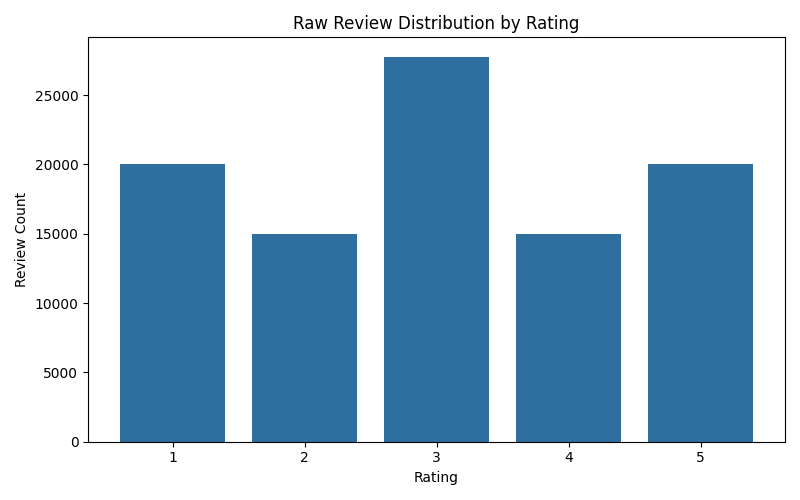

**docs\figures\01_data_acquisition\sentiment_distribution_raw.png**

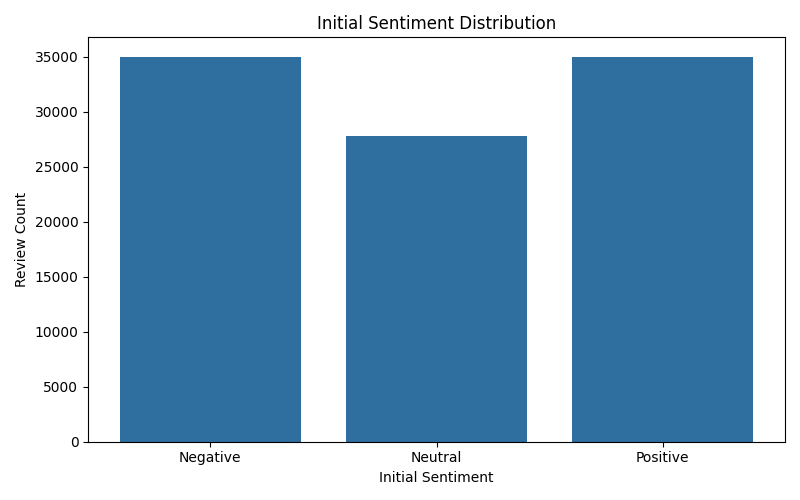

**docs\figures\01_data_acquisition\text_length_histogram_raw.png**

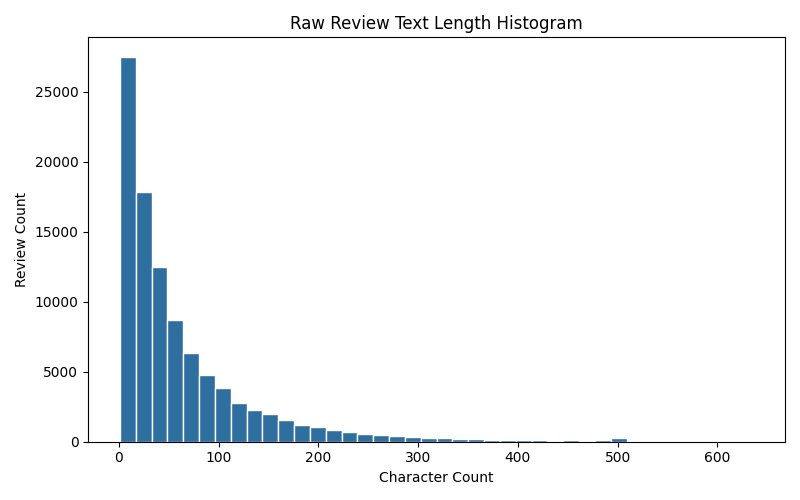

**docs\figures\01_data_acquisition\text_length_boxplot_raw.png**

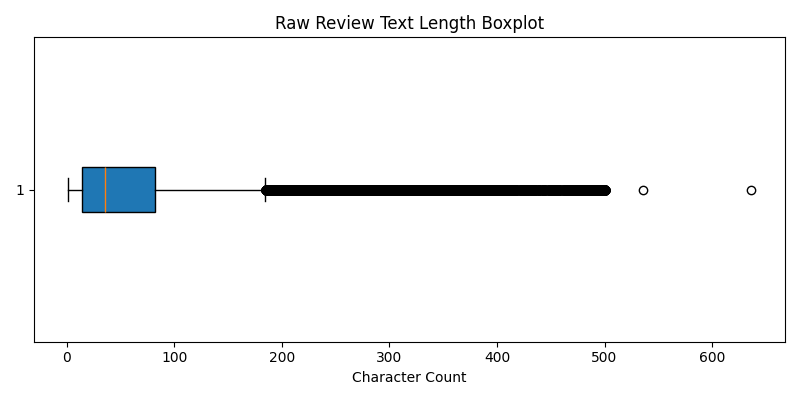

**docs\figures\01_data_acquisition\temporal_distribution_raw.png**

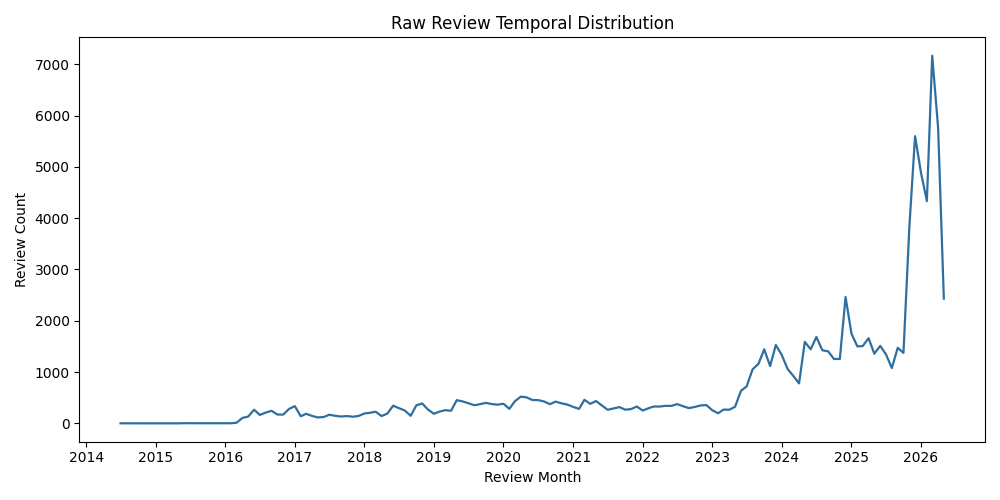

**docs\figures\01_data_acquisition\temporal_distribution_by_rating_raw.png**

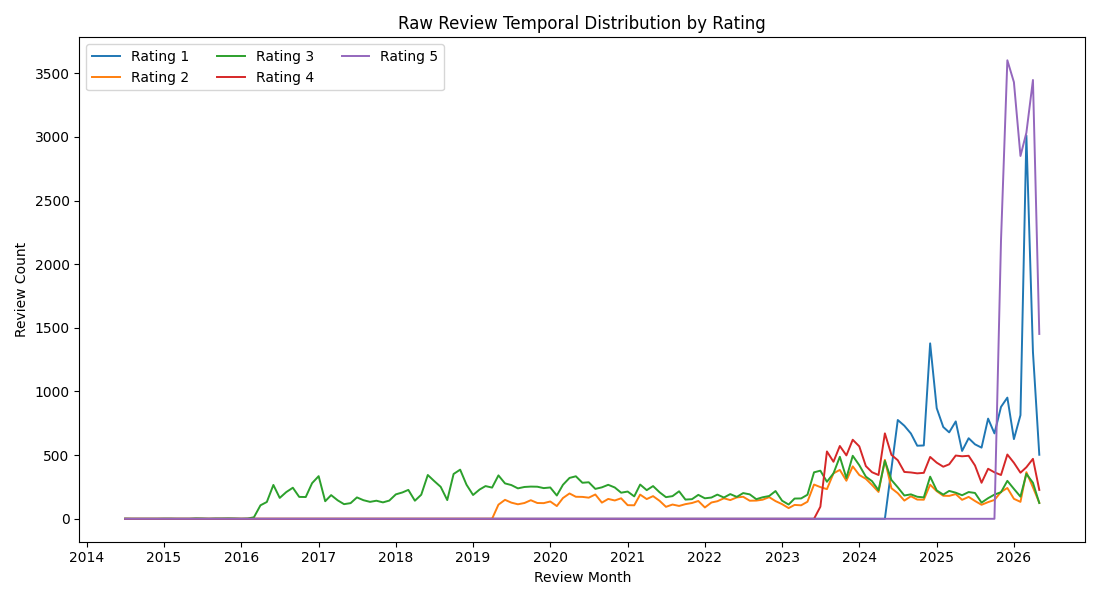

**docs\figures\01_data_acquisition\scraping_quota_achievement.png**

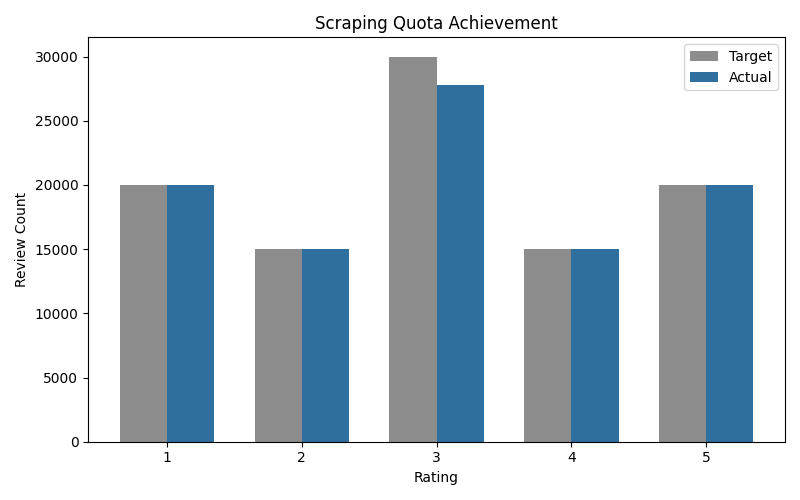

**docs\figures\01_data_acquisition\missing_value_summary.png**

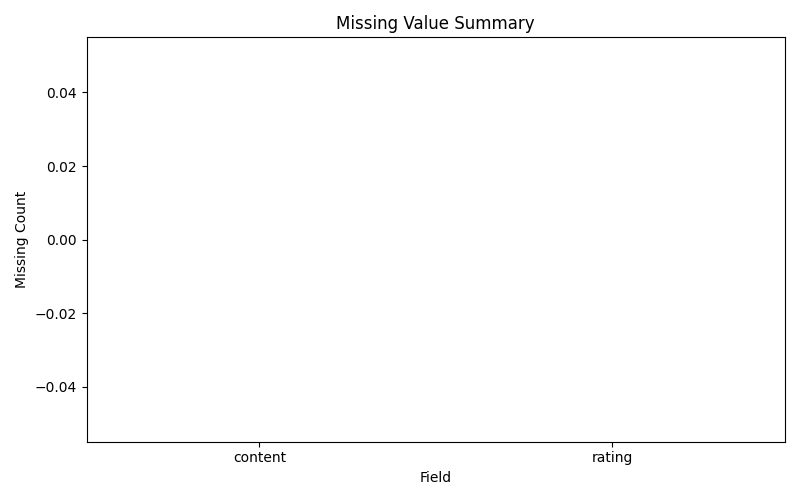

In [6]:
FIG01_DIR = DOCS_FIGURES_DIR / "01_data_acquisition"
figure_files = [
    "rating_distribution_raw.png",
    "sentiment_distribution_raw.png",
    "text_length_histogram_raw.png",
    "text_length_boxplot_raw.png",
    "temporal_distribution_raw.png",
    "temporal_distribution_by_rating_raw.png",
    "scraping_quota_achievement.png",
    "missing_value_summary.png",
]
show_figures([FIG01_DIR / filename for filename in figure_files], "Data Acquisition Figures")


## Interpretation Notes

The cell below derives thesis-facing interpretation from the available summaries and row counts.


In [7]:
notes = []

summary = acquisition_summaries.get("Data acquisition summary") or {}
rows_per_rating = summary.get("rows_per_rating") or {}
if rows_per_rating:
    notes.append(f"Summary rows per rating: `{rows_per_rating}`.")
elif raw_counts_df["actual_rows"].notna().any():
    rows_from_files = {int(row.rating): int(row.actual_rows) for row in raw_counts_df.itertuples() if pd.notna(row.actual_rows)}
    notes.append(f"Rows per rating from local raw CSV files: `{rows_from_files}`.")
else:
    notes.append("Raw per-rating CSV files are not available in this checkout; this is expected when ignored raw data is not copied locally.")

rating_3_row = raw_counts_df.loc[raw_counts_df["rating"] == 3].iloc[0]
if pd.notna(rating_3_row["actual_rows"]):
    rating_3_actual = int(rating_3_row["actual_rows"])
    rating_3_target = int(rating_3_row["target_rows"])
    if rating_3_actual < rating_3_target:
        notes.append(f"Rating 3 reached `{rating_3_actual:,}` of `{rating_3_target:,}` target rows, so Neutral availability is a documented data limitation.")
    else:
        notes.append("Rating 3 reached the configured target quota.")
else:
    quota_table = loaded_eda01_tables.get("scraping_quota_achievement.csv")
    if quota_table is not None and "rating" in quota_table.columns:
        rating_3_quota = quota_table.loc[quota_table["rating"] == 3]
        if not rating_3_quota.empty:
            notes.append(f"Rating 3 quota evidence from metrics: `{rating_3_quota.to_dict(orient='records')[0]}`.")

for key in ["duplicate_external_id_count", "missing_content_count", "missing_rating_count"]:
    if key in summary:
        notes.append(f"{key}: `{summary[key]}`.")

notes.append("Next step: continue with `02_preprocessing.ipynb` for relabeling, text normalization, and preprocessing EDA.")

display(Markdown("\n".join(f"- {note}" for note in notes)))


- Summary rows per rating: `{'1': 20000, '2': 15000, '3': 27782, '4': 15000, '5': 20000}`.
- Rating 3 reached `27,782` of `30,000` target rows, so Neutral availability is a documented data limitation.
- duplicate_external_id_count: `0`.
- missing_content_count: `0`.
- missing_rating_count: `0`.
- Next step: continue with `02_preprocessing.ipynb` for relabeling, text normalization, and preprocessing EDA.